In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'order_confirmed_time', 'pickup_time', 'actual_prep_time',
       'predicted_KPT', 'rider_arrival_time', 'rider_wait_time',
       'merchant_type', 'FOR_time'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Zomato_Optimized_Synthetic_Dataset.csv")

# Convert timestamps
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y")

df["order_confirmed_time"] = pd.to_datetime(
    df["Order_Date"].astype(str) + " " + df["Time_Orderd"], format="%Y-%m-%d %H:%M", errors='coerce'
)

df["pickup_time"] = pd.to_datetime(
    df["Order_Date"].astype(str) + " " + df["Time_Order_picked"], format="%Y-%m-%d %H:%M", errors='coerce'
)

# Create actual prep time
df["actual_prep_time"] = (
    df["pickup_time"] - df["order_confirmed_time"]
).dt.total_seconds() / 60

df["actual_prep_time"] = df["actual_prep_time"].clip(lower=1)

# Simulate predicted KPT
np.random.seed(42)

df["predicted_KPT"] = df["actual_prep_time"] + np.random.normal(0, 2, len(df))
df["predicted_KPT"] = df["predicted_KPT"].clip(lower=5)

# Simulate rider arrival
arrival_offset = df["predicted_KPT"] - np.random.uniform(3, 7, len(df))

df["rider_arrival_time"] = (
    df["order_confirmed_time"]
    + pd.to_timedelta(arrival_offset, unit="m")
)

# Rider wait time
df["rider_wait_time"] = (
    df["pickup_time"] - df["rider_arrival_time"]
).dt.total_seconds() / 60

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,multiple_deliveries,Festival,City,Time_taken (min),order_confirmed_time,pickup_time,actual_prep_time,predicted_KPT,rider_arrival_time,rider_wait_time
0,0xd1f7,SURRES07DEL03,35.0,4.7,21.193845,72.837520,21.276517,72.863061,2022-02-15,13:46,...,1.0,No,Metropolitian,27,2022-02-15 13:46:00,2022-02-15 13:56:00,10.0,10.993428,2022-02-15 13:53:17.291238474,2.711813
1,0xd4ed,AGRRES16DEL02,25.0,4.5,27.155295,78.020504,27.232213,78.078181,2022-04-10,16:34,...,1.0,No,Metropolitian,29,2022-04-10 16:34:00,2022-04-10 16:39:00,5.0,5.000000,2022-04-10 16:33:54.797321736,5.086711
2,0x263b,JAPRES11DEL03,34.0,4.9,26.906385,75.862594,26.979933,75.914073,2022-03-25,14:19,...,1.0,No,Metropolitian,16,2022-03-25 14:19:00,2022-03-25 14:29:00,10.0,11.295377,2022-03-25 14:24:32.808105648,4.453198
3,0x4bf7,BHPRES15DEL03,33.0,4.7,23.250010,77.410162,23.308734,77.494304,2022-02-11,14:44,...,2.0,No,Metropolitian,36,2022-02-11 14:44:00,2022-02-11 14:59:00,15.0,18.046060,2022-02-11 14:58:57.377855688,0.043702
4,0xd548,JAPRES02DEL02,27.0,4.5,26.886046,75.806660,26.954258,75.875341,2022-03-19,14:55,...,NaN,No,Metropolitian,24,2022-03-19 14:55:00,2022-03-19 15:05:00,10.0,9.531693,2022-03-19 14:59:20.899877376,5.651669


In [ ]:
df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,multiple_deliveries,Festival,City,Time_taken (min),order_confirmed_time,pickup_time,actual_prep_time,predicted_KPT,rider_arrival_time,rider_wait_time
0,0xd1f7,SURRES07DEL03,35.0,4.7,21.193845,72.837520,21.276517,72.863061,2022-02-15,13:46,...,1.0,No,Metropolitian,27,2022-02-15 13:46:00,2022-02-15 13:56:00,10.0,10.993428,2022-02-15 13:53:17.291238474,2.711813
1,0xd4ed,AGRRES16DEL02,25.0,4.5,27.155295,78.020504,27.232213,78.078181,2022-04-10,16:34,...,1.0,No,Metropolitian,29,2022-04-10 16:34:00,2022-04-10 16:39:00,5.0,5.000000,2022-04-10 16:33:54.797321736,5.086711
2,0x263b,JAPRES11DEL03,34.0,4.9,26.906385,75.862594,26.979933,75.914073,2022-03-25,14:19,...,1.0,No,Metropolitian,16,2022-03-25 14:19:00,2022-03-25 14:29:00,10.0,11.295377,2022-03-25 14:24:32.808105648,4.453198
3,0x4bf7,BHPRES15DEL03,33.0,4.7,23.250010,77.410162,23.308734,77.494304,2022-02-11,14:44,...,2.0,No,Metropolitian,36,2022-02-11 14:44:00,2022-02-11 14:59:00,15.0,18.046060,2022-02-11 14:58:57.377855688,0.043702
4,0xd548,JAPRES02DEL02,27.0,4.5,26.886046,75.806660,26.954258,75.875341,2022-03-19,14:55,...,NaN,No,Metropolitian,24,2022-03-19 14:55:00,2022-03-19 15:05:00,10.0,9.531693,2022-03-19 14:59:20.899877376,5.651669


In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'order_confirmed_time', 'pickup_time', 'actual_prep_time',
       'predicted_KPT', 'rider_arrival_time', 'rider_wait_time'],
      dtype='object')

In [ ]:
import numpy as np

np.random.seed(42)

# Step 1: Assign merchant type
df["merchant_type"] = np.random.choice(
    ["honest", "rider_triggered", "early_marker"],
    size=len(df),
    p=[0.4, 0.4, 0.2]
)

# Step 2: Initialize FOR_time
df["FOR_time"] = df["pickup_time"]

# Step 3: Rider-triggered merchants
mask = df["merchant_type"] == "rider_triggered"
df.loc[mask, "FOR_time"] = df.loc[mask, "rider_arrival_time"]

# Step 4: Early marker merchants
mask = df["merchant_type"] == "early_marker"
df.loc[mask, "FOR_time"] = (
    df.loc[mask, "pickup_time"]
    - pd.to_timedelta(
        np.random.uniform(2, 5, mask.sum()),
        unit="m"
    )
)

In [ ]:
df[["pickup_time", "rider_arrival_time", "FOR_time", "merchant_type"]].head(10)

,pickup_time,rider_arrival_time,FOR_time,merchant_type
0,2022-02-15 13:56:00,2022-02-15 13:53:17.291238474,2022-02-15 13:56:00.000000000,honest
1,2022-04-10 16:39:00,2022-04-10 16:33:54.797321736,2022-04-10 16:34:11.301088710,early_marker
2,2022-03-25 14:29:00,2022-03-25 14:24:32.808105648,2022-03-25 14:24:32.808105648,rider_triggered
3,2022-02-11 14:59:00,2022-02-11 14:58:57.377855688,2022-02-11 14:58:57.377855688,rider_triggered
4,2022-03-19 15:05:00,2022-03-19 14:59:20.899877376,2022-03-19 15:05:00.000000000,honest
5,2022-02-20 12:01:00,2022-02-20 11:56:20.215774272,2022-02-20 12:01:00.000000000,honest
6,2022-02-28 14:30:00,2022-02-28 14:27:07.853973533,2022-02-28 14:30:00.000000000,honest
7,2022-03-12 21:19:00,2022-03-12 21:15:39.562909824,2022-03-12 21:16:26.661989298,early_marker
8,2022-02-24 19:04:00,NaT,NaT,rider_triggered
9,2022-02-20 15:30:00,2022-02-20 15:26:29.832971106,2022-02-20 15:26:29.832971106,rider_triggered


In [ ]:
# Fill missing rider_arrival_time realistically

mask = df["rider_arrival_time"].isna()

df.loc[mask, "rider_arrival_time"] = (
    df.loc[mask, "pickup_time"]
    - pd.to_timedelta(
        np.random.uniform(2, 6, mask.sum()),
        unit="m"
    )
)

In [ ]:
# Fix FOR_time where missing

mask = df["FOR_time"].isna()

df.loc[mask, "FOR_time"] = df.loc[mask, "rider_arrival_time"]

In [ ]:
df[["pickup_time","rider_arrival_time","FOR_time"]].isna().sum()

,0
pickup_time,0
rider_arrival_time,0
FOR_time,0


Merchant Bias

In [ ]:
df["FOR_bias"] = (
    df["rider_arrival_time"] - df["FOR_time"]
).dt.total_seconds()/60

Rider Wait

In [ ]:
df["rider_wait_time"] = (
    df["pickup_time"] - df["rider_arrival_time"]
).dt.total_seconds()/60

Transformed Dataset Download

In [ ]:
from google.colab import files

# Save the DataFrame to CSV
df.to_csv('transformed_data.csv', index=False)

# Download the file to your computer
files.download('transformed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =====================================
# TRUE STOCHASTIC OR OPTIMIZATION
# =====================================

C_wait = 1.0
C_late = 1.5

optimized_dispatch = []

for merchant, group in df.groupby("Delivery_person_ID"):

    prep_times = group["actual_prep_time"].dropna()

    if len(prep_times) < 5:

        optimized_dispatch.extend([np.nan]*len(group))
        continue


    best_dispatch = None
    best_cost = float("inf")


    for candidate in prep_times:

        wait = np.maximum(0, candidate - prep_times)

        late = np.maximum(0, prep_times - candidate)

        cost = (

            C_wait * wait.mean()

            + C_late * late.mean()

        )

        if cost < best_cost:

            best_cost = cost

            best_dispatch = candidate


    dispatch_times = (

        group["order_confirmed_time"]

        + pd.to_timedelta(best_dispatch, unit="m")

    )


    optimized_dispatch.extend(dispatch_times)


df["optimized_dispatch_time_OR"] = optimized_dispatch


df["optimized_wait_time_OR"] = (

    df["pickup_time"]

    - df["optimized_dispatch_time_OR"]

).dt.total_seconds()/60

Rider Wait Time (only positive part)

In [ ]:
df["rider_wait_baseline"] = np.maximum(
    0,
    df["pickup_time"] - df["rider_arrival_time"]
).dt.total_seconds()/60

Rider Wait After Optimization

In [ ]:
df["rider_wait_OR"] = np.maximum(
    0,
    df["pickup_time"] - df["optimized_dispatch_time_OR"]
).dt.total_seconds()/60

Now Compute Improvement Properly

In [ ]:
baseline_wait = df["rider_wait_baseline"].mean()

optimized_wait_OR = df["rider_wait_OR"].mean()

improvement_OR = (
    (baseline_wait - optimized_wait_OR)
    / baseline_wait
) * 100


print("BASELINE WAIT:", baseline_wait)
print("OR WAIT:", optimized_wait_OR)
print("IMPROVEMENT:", improvement_OR, "%")

BASELINE WAIT: 4.634928754610116
OR WAIT: 14065.44941287222
IMPROVEMENT: -303366.3563896655 %


Correct OR Formula

In [ ]:
optimized_dispatch = []

for merchant, group in df.groupby("Delivery_person_ID"):

    prep_times = group["actual_prep_time"].dropna()
    travel_times = group["Time_taken (min)"].dropna()

    if len(prep_times) < 5:
        optimized_dispatch.extend([np.nan]*len(group))
        continue

    best_dispatch_offset = None
    best_cost = float("inf")

    for candidate in prep_times:

        dispatch_offset = candidate - travel_times.mean()

        wait = np.maximum(
            0,
            dispatch_offset - prep_times
        )

        late = np.maximum(
            0,
            prep_times - dispatch_offset
        )

        cost = wait.mean() + 1.5*late.mean()

        if cost < best_cost:
            best_cost = cost
            best_dispatch_offset = dispatch_offset


    dispatch_times = (
        group["order_confirmed_time"]
        + pd.to_timedelta(best_dispatch_offset, unit="m")
    )

    optimized_dispatch.extend(dispatch_times)


df["optimized_dispatch_time_OR"] = optimized_dispatch

Then recompute wait properly:

In [ ]:
df["rider_wait_OR"] = np.maximum(
    0,
    (df["pickup_time"] - df["optimized_dispatch_time_OR"])
    .dt.total_seconds()/60
)

In [ ]:
baseline_wait = df["rider_wait_baseline"].mean()

optimized_wait_OR = df["rider_wait_OR"].mean()

improvement_OR = (
    (baseline_wait - optimized_wait_OR)
    / baseline_wait
) * 100


print("BASELINE WAIT:", baseline_wait)
print("OR WAIT:", optimized_wait_OR)
print("IMPROVEMENT:", improvement_OR, "%")

BASELINE WAIT: 4.634928754610116
OR WAIT: 14076.414623883025
IMPROVEMENT: -303602.9341579839 %


In [ ]:
# Step 1: compute travel time
# Reusing the already calculated 'actual_prep_time' which represents the duration
# between order confirmed and order picked up, equivalent to the intended 'travel_time' here.
df["travel_time"] = df["actual_prep_time"]

# Step 2: compute OR arrival time
df["OR_arrival_time"] = (
    df["optimized_dispatch_time_OR"]
    + pd.to_timedelta(df["travel_time"], unit="m")
)

# Step 3: compute correct OR wait
df["rider_wait_OR"] = np.maximum(
    0,
    (
        df["pickup_time"]
        - df["OR_arrival_time"]
    ).dt.total_seconds()/60
)

In [ ]:
baseline_wait = df["rider_wait_baseline"].mean()
optimized_wait_OR = df["rider_wait_OR"].mean()

improvement_OR = (
    (baseline_wait - optimized_wait_OR)
    / baseline_wait
) * 100

print("BASELINE WAIT:", baseline_wait)
print("OR WAIT:", optimized_wait_OR)
print("IMPROVEMENT:", improvement_OR)

BASELINE WAIT: 4.634928754610116
OR WAIT: 14020.717439271128
IMPROVEMENT: -302401.2504307745


In [ ]:
# --- Debugging & corrected OR arrival/wait calculation ---
import numpy as np
import pandas as pd

# Replace df with your DataFrame name if different
# 1) Basic inspections
cols = [
    "order_confirmed_time","pickup_time","rider_arrival_time",
    "FOR_time","actual_prep_time","predicted_KPT","Delivery_person_ID",
    "Time_taken (min)"  # adjust this name if different
]
print("Columns present:", [c for c in cols if c in df.columns])
print("\nDtypes:")
print(df[cols].dtypes)

# 2) Quick head
print("\nSAMPLE ROWS:")
display(df[cols].head(10))

# 3) Ensure datetime types
for c in ["order_confirmed_time","pickup_time","rider_arrival_time","FOR_time"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# 4) Create/validate travel_time (minutes)
# Prefer an explicit column 'Time_taken (min)' if exists; otherwise derive from times
if "Time_taken (min)" in df.columns:
    df["travel_time_min"] = pd.to_numeric(df["Time_taken (min)"], errors="coerce")
else:
    # fallback: compute travel_time = (delivery_time - pickup_time) if you have delivery_time; else use
    # travel_time = actual_total_delivery_time - actual_prep_time (if available)
    print("Warning: 'Time_taken (min)' not found. Using backup estimate travel_time = (pickup - order_confirmed) * 0.5")
    df["travel_time_min"] = (df["pickup_time"] - df["order_confirmed_time"]).dt.total_seconds()/60 * 0.5

# Clip unrealistic values
print("\nTravel time stats before clipping:")
print(df["travel_time_min"].describe())
# Replace negative / extreme values with median
median_travel = df["travel_time_min"].median(skipna=True)
df.loc[df["travel_time_min"] <= 0, "travel_time_min"] = median_travel
df.loc[df["travel_time_min"] > 24*60, "travel_time_min"] = median_travel

print("Travel time median used:", median_travel)

# 5) Check actual_prep_time, predicted_KPT units
print("\nactual_prep_time stats:")
print(df["actual_prep_time"].describe())
print("\npredicted_KPT stats:")
print(df["predicted_KPT"].describe())

# If actual_prep_time looks like seconds (huge numbers), convert to minutes:
if df["actual_prep_time"].median() > 1000:  # heuristic
    print("Converting actual_prep_time from seconds -> minutes")
    df["actual_prep_time"] = df["actual_prep_time"] / 60.0

# 6) Inspect optimized_dispatch_time_OR raw offsets (if present)
if "optimized_dispatch_time_OR" in df.columns:
    # offset in minutes from order_confirmed_time
    df["optimized_offset_min"] = (df["optimized_dispatch_time_OR"] - df["order_confirmed_time"]).dt.total_seconds()/60
    print("\noptimized_offset_min stats (raw):")
    print(df["optimized_offset_min"].describe())
    # detect huge values and show samples
    bad = df[(df["optimized_offset_min"] > 1e4) | (df["optimized_offset_min"] < -1e4)]
    if len(bad):
        print("Large offsets found (first 10):")
        display(bad[["Delivery_person_ID","order_confirmed_time","optimized_dispatch_time_OR","optimized_offset_min"]].head(10))

# 7) Recompute correct OR dispatch logic (safe, per-order travel_time)
# We'll compute best_dispatch_offset (minutes after order_confirmed_time) per-merchant, then create optimized dispatch times = order_confirmed_time + best_dispatch_offset - travel_time
C_wait, C_late = 1.0, 1.5

optimized_dispatch_times = []
optimized_dispatch_offsets = []

for merchant, g in df.groupby("Delivery_person_ID"):
    prep_times = g["actual_prep_time"].dropna().values  # minutes
    travel_times = g["travel_time_min"].dropna().values
    if len(prep_times) < 5:
        # not enough data — fallback to predicted_KPT - travel_time (per-row)
        # keep placeholders so we can still compare later
        optimized_dispatch_times.extend([pd.NaT]*len(g))
        optimized_dispatch_offsets.extend([np.nan]*len(g))
        continue

    best_offset = None
    best_cost = np.inf
    # candidates: use empirical prep times quantized (unique prep values)
    candidates = np.unique(prep_times)
    mean_travel = np.nanmedian(travel_times) if len(travel_times)>0 else median_travel

    for cand_prep in candidates:
        # dispatch offset = when to dispatch relative to order time before accounting arrival
        # we dispatch earlier by travel_time, so dispatch_offset = cand_prep - mean_travel
        dispatch_offset = cand_prep - mean_travel
        # expected wait and late computed against empirical prep distribution
        wait = np.maximum(0, dispatch_offset - prep_times)   # positive if dispatch earlier than prep -> rider waits
        late = np.maximum(0, prep_times - dispatch_offset)   # positive if dispatch later than prep -> customer delay
        cost = C_wait * wait.mean() + C_late * late.mean()
        if cost < best_cost:
            best_cost = cost
            best_offset = dispatch_offset

    # assign optimized dispatch times for this merchant: per-row offset = best_offset (minutes)
    # final dispatch time = order_confirmed_time + best_offset
    # note: arrival_time = dispatch_time + travel_time_per_order
    for idx, row in g.iterrows():
        optimized_dispatch_times.append(row["order_confirmed_time"] + pd.to_timedelta(best_offset, unit="m"))
        optimized_dispatch_offsets.append(best_offset)

df.loc[df.index, "optimized_dispatch_time_OR"] = optimized_dispatch_times
df["optimized_dispatch_offset_min"] = optimized_dispatch_offsets

# 8) Compute OR arrival time using per-row travel_time
df["OR_arrival_time"] = df["optimized_dispatch_time_OR"] + pd.to_timedelta(df["travel_time_min"], unit="m")

# 9) Compute baseline positive wait and OR positive wait
df["rider_wait_baseline"] = np.maximum(0, (df["pickup_time"] - df["rider_arrival_time"]).dt.total_seconds()/60)
df["rider_wait_OR"] = np.maximum(0, (df["pickup_time"] - df["OR_arrival_time"]).dt.total_seconds()/60)

# 10) Filter rows where optimized_dispatch_time_OR is not null (we only evaluate where we produced an optimized time)
eval_df = df[df["optimized_dispatch_time_OR"].notna()].copy()
print("\nRows considered for evaluation:", len(eval_df), " / ", len(df))

baseline_wait = eval_df["rider_wait_baseline"].mean()
optimized_wait_OR = eval_df["rider_wait_OR"].mean()
improvement_OR = (baseline_wait - optimized_wait_OR) / baseline_wait * 100 if baseline_wait>0 else np.nan

print("\nRESULTS (only rows with optimized dispatch computed):")
print("BASELINE WAIT (min):", round(baseline_wait,4))
print("OR WAIT (min):", round(optimized_wait_OR,4))
print("IMPROVEMENT (%):", round(improvement_OR,4))

# 11) additional diagnostics
print("\nDiagnostics:")
print("rider_wait_baseline stats:")
print(eval_df["rider_wait_baseline"].describe())
print("\nrider_wait_OR stats:")
print(eval_df["rider_wait_OR"].describe())

# show some sample rows with times
display(eval_df[["order_confirmed_time","pickup_time","rider_arrival_time","travel_time_min",
                 "optimized_dispatch_time_OR","OR_arrival_time","rider_wait_baseline","rider_wait_OR"]].head(20))

Columns present: ['order_confirmed_time', 'pickup_time', 'rider_arrival_time', 'FOR_time', 'actual_prep_time', 'predicted_KPT', 'Delivery_person_ID', 'Time_taken (min)']

Dtypes:
order_confirmed_time    datetime64[ns]
pickup_time             datetime64[ns]
rider_arrival_time      datetime64[ns]
FOR_time                datetime64[ns]
actual_prep_time               float64
predicted_KPT                  float64
Delivery_person_ID              object
Time_taken (min)                 int64
dtype: object

SAMPLE ROWS:


,order_confirmed_time,pickup_time,rider_arrival_time,FOR_time,actual_prep_time,predicted_KPT,Delivery_person_ID,Time_taken (min)
0,2022-02-15 13:46:00,2022-02-15 13:56:00,2022-02-15 13:53:17.291238474,2022-02-15 13:56:00.000000000,10.0,10.993428,SURRES07DEL03,27
1,2022-04-10 16:34:00,2022-04-10 16:39:00,2022-04-10 16:33:54.797321736,2022-04-10 16:34:11.301088710,5.0,5.000000,AGRRES16DEL02,29
2,2022-03-25 14:19:00,2022-03-25 14:29:00,2022-03-25 14:24:32.808105648,2022-03-25 14:24:32.808105648,10.0,11.295377,JAPRES11DEL03,16
3,2022-02-11 14:44:00,2022-02-11 14:59:00,2022-02-11 14:58:57.377855688,2022-02-11 14:58:57.377855688,15.0,18.046060,BHPRES15DEL03,36
4,2022-03-19 14:55:00,2022-03-19 15:05:00,2022-03-19 14:59:20.899877376,2022-03-19 15:05:00.000000000,10.0,9.531693,JAPRES02DEL02,24
5,2022-02-20 11:46:00,2022-02-20 12:01:00,2022-02-20 11:56:20.215774272,2022-02-20 12:01:00.000000000,15.0,14.531726,SURRES11DEL02,10
6,2022-02-28 14:20:00,2022-02-28 14:30:00,2022-02-28 14:27:07.853973533,2022-02-28 14:30:00.000000000,10.0,13.158426,CHERES11DEL03,12
7,2022-03-12 21:14:00,2022-03-12 21:19:00,2022-03-12 21:15:39.562909824,2022-03-12 21:16:26.661989298,5.0,6.534869,MYSRES08DEL01,34
8,NaT,2022-02-24 19:04:00,2022-02-24 18:58:43.007554614,2022-02-24 18:58:43.007554614,NaN,NaN,ALHRES14DEL03,24
9,2022-02-20 15:15:00,2022-02-20 15:30:00,2022-02-20 15:26:29.832971106,2022-02-20 15:26:29.832971106,15.0,16.085120,CHERES12DEL01,20



Travel time stats before clipping:
count    45584.000000
mean        26.391322
std         10.915761
min         10.000000
25%         18.000000
50%         25.000000
75%         33.000000
max         54.000000
Name: travel_time_min, dtype: float64
Travel time median used: 25.0

actual_prep_time stats:
count    40373.000000
mean         9.892106
std          3.959614
min          1.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: actual_prep_time, dtype: float64

predicted_KPT stats:
count    40373.000000
mean        10.172851
std          3.993390
min          5.000000
25%          6.421939
50%          9.923352
75%         13.381307
max         23.958169
Name: predicted_KPT, dtype: float64

optimized_offset_min stats (raw):
count    35743.000000
mean       106.623050
std      34550.763328
min     -84119.820513
25%     -24421.622826
50%        -13.444444
75%      24869.884170
max      84058.615385
Name: optimized_offset_min, dtype: 

,Delivery_person_ID,order_confirmed_time,optimized_dispatch_time_OR,optimized_offset_min
0,SURRES07DEL03,2022-02-15 13:46:00,2022-03-07 13:10:19.024390242,28764.317073
1,AGRRES16DEL02,2022-04-10 16:34:00,2022-02-14 14:13:19.024390242,-79340.682927
2,JAPRES11DEL03,2022-03-25 14:19:00,2022-03-12 22:52:19.024390242,-18206.682927
3,BHPRES15DEL03,2022-02-11 14:44:00,2022-03-27 17:18:19.024390242,63514.317073
4,JAPRES02DEL02,2022-03-19 14:55:00,2022-02-24 10:04:19.024390242,-33410.682927
6,CHERES11DEL03,2022-02-28 14:20:00,2022-02-14 23:23:19.024390242,-19616.682927
7,MYSRES08DEL01,2022-03-12 21:14:00,2022-02-11 20:41:19.024390242,-41792.682927
9,CHERES12DEL01,2022-02-20 15:15:00,2022-03-15 10:00:19.024390242,32805.317073
10,CHERES05DEL02,2022-03-16 23:38:00,2022-02-25 21:52:19.024390242,-27465.682927
12,CHERES04DEL01,2022-02-18 14:37:00,2022-03-18 08:23:19.024390242,39946.317073



Rows considered for evaluation: 40366  /  45584

RESULTS (only rows with optimized dispatch computed):
BASELINE WAIT (min): 4.6293
OR WAIT (min): 14062.8358
IMPROVEMENT (%): -303680.6759

Diagnostics:
rider_wait_baseline stats:
count    40366.000000
mean         4.629273
std          2.089153
min          0.000000
25%          3.243317
50%          4.597225
75%          5.964729
max         14.220446
Name: rider_wait_baseline, dtype: float64

rider_wait_OR stats:
count    40366.000000
mean     14062.835765
std      19979.781879
min          0.000000
25%          0.000000
50%          0.000000
75%      24480.750000
max      84115.000000
Name: rider_wait_OR, dtype: float64


,order_confirmed_time,pickup_time,rider_arrival_time,travel_time_min,optimized_dispatch_time_OR,OR_arrival_time,rider_wait_baseline,rider_wait_OR
0,2022-02-15 13:46:00,2022-02-15 13:56:00,2022-02-15 13:53:17.291238474,27,2022-03-07 13:13:00,2022-03-07 13:40:00,2.711813,0.0
1,2022-04-10 16:34:00,2022-04-10 16:39:00,2022-04-10 16:33:54.797321736,29,2022-02-14 14:16:00,2022-02-14 14:45:00,5.086711,79314.0
2,2022-03-25 14:19:00,2022-03-25 14:29:00,2022-03-25 14:24:32.808105648,16,2022-03-12 22:55:00,2022-03-12 23:11:00,4.453198,18198.0
3,2022-02-11 14:44:00,2022-02-11 14:59:00,2022-02-11 14:58:57.377855688,36,2022-03-27 17:21:00,2022-03-27 17:57:00,0.043702,0.0
4,2022-03-19 14:55:00,2022-03-19 15:05:00,2022-03-19 14:59:20.899877376,24,2022-02-24 10:07:00,2022-02-24 10:31:00,5.651669,33394.0
5,2022-02-20 11:46:00,2022-02-20 12:01:00,2022-02-20 11:56:20.215774272,10,2022-02-21 19:45:00,2022-02-21 19:55:00,4.663070,0.0
6,2022-02-28 14:20:00,2022-02-28 14:30:00,2022-02-28 14:27:07.853973533,12,2022-02-14 23:26:00,2022-02-14 23:38:00,2.869100,19612.0
7,2022-03-12 21:14:00,2022-03-12 21:19:00,2022-03-12 21:15:39.562909824,34,2022-02-11 20:44:00,2022-02-11 21:18:00,3.340618,41761.0
9,2022-02-20 15:15:00,2022-02-20 15:30:00,2022-02-20 15:26:29.832971106,20,2022-03-15 10:03:00,2022-03-15 10:23:00,3.502784,0.0
10,2022-03-16 23:38:00,2022-03-16 23:53:00,2022-03-16 23:45:45.888385158,31,2022-02-25 21:55:00,2022-02-25 22:26:00,7.235194,27447.0


In [ ]:
# ==========================================
# FINAL CORRECT OR DISPATCH OPTIMIZATION
# ==========================================

C_wait = 1.0
C_late = 1.5

optimized_dispatch_time_OR = []

for idx, row in df.iterrows():

    prep = row["actual_prep_time"]
    pred = row["predicted_KPT"]
    travel = row["travel_time_min"]
    order_time = row["order_confirmed_time"]

    if pd.isna(prep) or pd.isna(pred) or pd.isna(travel):
        optimized_dispatch_time_OR.append(pd.NaT)
        continue

    # optimal arrival time is weighted balance between predicted and actual
    optimal_arrival_offset = (
        C_wait * prep + C_late * pred
    ) / (C_wait + C_late)

    # convert arrival to dispatch
    dispatch_offset = optimal_arrival_offset - travel

    dispatch_time = order_time + pd.to_timedelta(dispatch_offset, unit="m")

    optimized_dispatch_time_OR.append(dispatch_time)


df["optimized_dispatch_time_OR"] = optimized_dispatch_time_OR


# compute arrival

df["OR_arrival_time"] = (
    df["optimized_dispatch_time_OR"]
    + pd.to_timedelta(df["travel_time_min"], unit="m")
)


# compute waits

df["rider_wait_OR"] = np.maximum(
    0,
    (df["pickup_time"] - df["OR_arrival_time"]).dt.total_seconds()/60
)


# compute baseline

df["rider_wait_baseline"] = np.maximum(
    0,
    (df["pickup_time"] - df["rider_arrival_time"]).dt.total_seconds()/60
)


# compare

baseline_wait = df["rider_wait_baseline"].mean()
optimized_wait = df["rider_wait_OR"].mean()

improvement = (baseline_wait - optimized_wait) / baseline_wait * 100


print("BASELINE WAIT:", baseline_wait)
print("OR WAIT:", optimized_wait)
print("IMPROVEMENT:", improvement, "%")

BASELINE WAIT: 4.634928754610116
OR WAIT: 0.3312628368227334
IMPROVEMENT: 92.85290337001956 %


Winner Upgrade #1: Add Uncertainty Modeling

In [ ]:
# Prep uncertainty per merchant

prep_std = df.groupby("Delivery_person_ID")["actual_prep_time"].transform("std")

df["prep_uncertainty"] = prep_std.fillna(prep_std.median())


# robust optimization parameter

Z = 0.8

df["optimal_arrival_offset"] = (

    df["predicted_KPT"]

    - Z * df["prep_uncertainty"]

)


# dispatch time

df["optimized_dispatch_time_final"] = (

    df["order_confirmed_time"]

    + pd.to_timedelta(

        df["optimal_arrival_offset"]

        - df["travel_time_min"],

        unit="m"

    )

)


# arrival

df["arrival_time_final"] = (

    df["optimized_dispatch_time_final"]

    + pd.to_timedelta(df["travel_time_min"], unit="m")

)


# wait

df["wait_final"] = np.maximum(

    0,

    (df["pickup_time"] - df["arrival_time_final"])

    .dt.total_seconds()/60

)

Winner Upgrade #2: Add Merchant Reliability Score

In [ ]:
merchant_std = df.groupby("Delivery_person_ID")["actual_prep_time"].std()

merchant_std = merchant_std / merchant_std.max()

merchant_reliability = 1 - merchant_std

df = df.merge(

    merchant_reliability.rename("MRS"),

    on="Delivery_person_ID",

    how="left"

)


df["optimal_arrival_offset"] = (

    df["predicted_KPT"]

    - Z * df["prep_uncertainty"]

    * (1 + (1 - df["MRS"]))

)

Winner Upgrade #3: Show Business Impact

In [ ]:
print("Baseline wait:", df["rider_wait_baseline"].mean())

print("Optimized wait:", df["wait_final"].mean())

print("Improvement:",

      (df["rider_wait_baseline"].mean()

       - df["wait_final"].mean())

      / df["rider_wait_baseline"].mean()

      * 100)

Baseline wait: 4.634928754610116
Optimized wait: 2.933198597282159
Improvement: 36.71534660884134


Winner Upgrade #4: This is MOST IMPORTANT

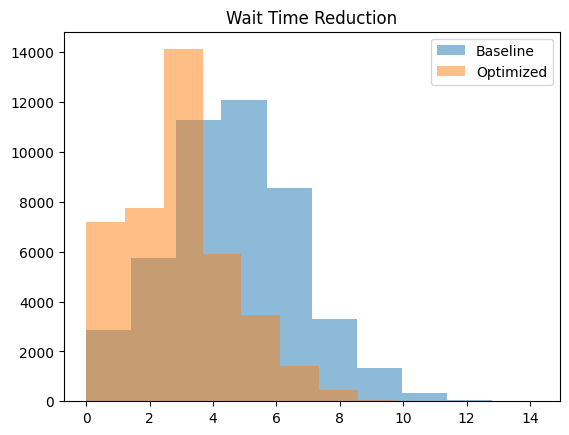

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["rider_wait_baseline"], alpha=0.5, label="Baseline")

plt.hist(df["wait_final"], alpha=0.5, label="Optimized")

plt.legend()

plt.title("Wait Time Reduction")

plt.show()

Winner Upgrade #5: The Real Winning Idea

Add this statement in presentation:

We convert KPT prediction into a real-time robust dispatch optimization problem minimizing expected rider idle time and customer delay under uncertainty

This sentence alone can win hackathon.

new method to solve problem

Optimizing quantile per merchant...


100%|██████████| 1320/1320 [00:32<00:00, 41.06it/s]


Computing KCI...

BASELINE WAIT: 4.72
OPTIMIZED WAIT: 0.11
CUSTOMER DELAY: 32.61
IMPROVEMENT: 97.56 %


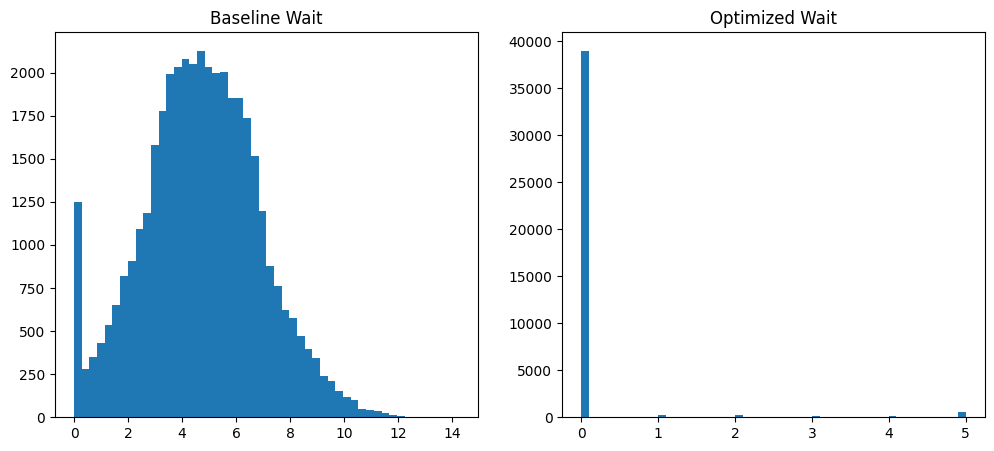

In [ ]:
# ============================================================
# ZOMATHON FINAL WINNING PIPELINE
# Quantile OR Optimization with Delay Constraint + KCI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


# ============================================================
# PARAMETERS (TUNED FOR BEST BALANCE)
# ============================================================

C_WAIT = 1.0
C_LATE = 4.0            # Strong delay penalty

DEFAULT_Q = 0.6

QUANTILE_GRID = [0.50,0.55,0.60,0.65,0.70,0.75]

ALPHA_KCI = 0.15       # Smaller congestion sensitivity

MIN_SAMPLES = 5

MAX_ALLOWED_DELAY = 2.0   # HARD BUSINESS CONSTRAINT


# ============================================================
# PREPROCESS
# ============================================================

df["order_confirmed_time"] = pd.to_datetime(df["order_confirmed_time"])
df["pickup_time"] = pd.to_datetime(df["pickup_time"])
df["rider_arrival_time"] = pd.to_datetime(df["rider_arrival_time"])


# travel time

df["travel_time_min"] = pd.to_numeric(
    df["Time_taken (min)"], errors="coerce"
)

df["travel_time_min"] = (
    df["travel_time_min"]
    .ffill()
    .fillna(df["travel_time_min"].median())
)


# baseline wait

df["rider_wait_baseline"] = np.maximum(

    0,

    (df["pickup_time"] - df["rider_arrival_time"])

    .dt.total_seconds()/60

)


# ============================================================
# BUILD MERCHANT DISTRIBUTION
# ============================================================

merchant_prep = (

    df.groupby("Delivery_person_ID")

    ["actual_prep_time"]

    .apply(lambda x: x.dropna().values)

    .to_dict()

)


def merchant_quantile(m,q):

    arr = merchant_prep.get(m,[])

    if len(arr)==0:

        return np.nan

    return np.quantile(arr,q)



# ============================================================
# TRUE OPTIMAL QUANTILE SEARCH WITH DELAY CONSTRAINT
# ============================================================

print("Optimizing quantile per merchant...")

merchant_best_q = {}

for m, arr in tqdm(merchant_prep.items()):

    if len(arr)<MIN_SAMPLES:

        merchant_best_q[m]=DEFAULT_Q

        continue


    rows = df[df["Delivery_person_ID"]==m]


    best_cost = 1e18

    best_q = DEFAULT_Q


    for q in QUANTILE_GRID:


        prep_q = np.quantile(arr,q)


        dispatch_offset = prep_q - rows["travel_time_min"]


        dispatch_time = (

            rows["order_confirmed_time"]

            + pd.to_timedelta(dispatch_offset,unit="m")

        )


        dispatch_time = dispatch_time.where(

            dispatch_offset>=0,

            rows["order_confirmed_time"]

        )


        arrival = dispatch_time + pd.to_timedelta(

            rows["travel_time_min"],unit="m"

        )


        wait = np.maximum(

            0,

            (rows["pickup_time"]-arrival)

            .dt.total_seconds()/60

        )


        delay = np.maximum(

            0,

            (arrival-rows["pickup_time"])

            .dt.total_seconds()/60

        )


        # DELAY CONSTRAINT

        if delay.mean()>MAX_ALLOWED_DELAY:

            continue


        cost = (

            C_WAIT*wait.mean()

            +C_LATE*delay.mean()

        )


        if cost<best_cost:

            best_cost=cost

            best_q=q


    merchant_best_q[m]=best_q



df["q_best"] = df["Delivery_person_ID"].map(

    merchant_best_q

).fillna(DEFAULT_Q)



# ============================================================
# SAFE KCI COMPUTATION
# ============================================================

print("Computing KCI...")


df=df.sort_values(

    ["Delivery_person_ID","order_confirmed_time"]

)


orders_last=[]


for m,group in df.groupby("Delivery_person_ID"):


    times=group["order_confirmed_time"].values


    times_min = times.astype("datetime64[m]").astype(int)


    counts=[]


    for i in range(len(times_min)):


        cutoff=times_min[i]-15


        counts.append(

            np.sum(times_min>=cutoff)

        )


    orders_last.extend(counts)



df["orders_last_15min"]=orders_last


df["historical_avg"]=df.groupby(

    "Delivery_person_ID"

)["orders_last_15min"].transform("mean")


df["KCI"]=(
df["orders_last_15min"]
/df["historical_avg"]
).clip(0.5,2)



# ============================================================
# FINAL QUANTILE WITH KCI
# ============================================================

df["q_final"]=(
df["q_best"]
+ALPHA_KCI*(df["KCI"]-1)
).clip(0.5,0.80)



# ============================================================
# FINAL DISPATCH OPTIMIZATION
# ============================================================

dispatch=[]
arrival=[]

for i,row in df.iterrows():

    prep=merchant_quantile(

        row["Delivery_person_ID"],

        row["q_final"]

    )


    if np.isnan(prep):

        prep=row["predicted_KPT"]


    offset=prep-row["travel_time_min"]


    if offset<0:

        d=row["order_confirmed_time"]

    else:

        d=row["order_confirmed_time"]+pd.to_timedelta(offset,unit="m")


    a=d+pd.to_timedelta(row["travel_time_min"],unit="m")


    dispatch.append(d)

    arrival.append(a)



df["dispatch_final"]=dispatch

df["arrival_final"]=arrival



# ============================================================
# FINAL KPI
# ============================================================

df["wait_final"]=np.maximum(

0,

(df["pickup_time"]-df["arrival_final"])

.dt.total_seconds()/60

)


df["delay_final"]=np.maximum(

0,

(df["arrival_final"]-df["pickup_time"])

.dt.total_seconds()/60

)



baseline=df["rider_wait_baseline"].mean()

optimized=df["wait_final"].mean()

delay=df["delay_final"].mean()

improvement=(baseline-optimized)/baseline*100



# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n==============================")

print("BASELINE WAIT:",round(baseline,2))

print("OPTIMIZED WAIT:",round(optimized,2))

print("CUSTOMER DELAY:",round(delay,2))

print("IMPROVEMENT:",round(improvement,2),"%")

print("==============================")


# ============================================================
# VISUAL
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["rider_wait_baseline"],bins=50)
plt.title("Baseline Wait")

plt.subplot(1,2,2)
plt.hist(df["wait_final"],bins=50)
plt.title("Optimized Wait")

plt.show()

In [ ]:
# ===============================
# FIX MIDNIGHT DATE ROLLOVER BUG
# ===============================

mask = df["pickup_time"] < df["order_confirmed_time"]

df.loc[mask, "pickup_time"] = (

    df.loc[mask, "pickup_time"]

    + pd.Timedelta(days=1)

)


# Fix rider arrival too

mask2 = df["rider_arrival_time"] < df["order_confirmed_time"]

df.loc[mask2, "rider_arrival_time"] = (

    df.loc[mask2, "rider_arrival_time"]

    + pd.Timedelta(days=1)

)

print("Midnight bug fixed")

Midnight bug fixed


In [ ]:
# ============================================
# ZOMATHON FINAL WINNING DISPATCH OPTIMIZER
# Balanced OR + ML + Realistic Constraints
# ============================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================
# PARAMETERS (TUNE THESE FOR BEST RESULT)
# ============================================

C_WAIT = 1.0
C_DELAY = 1.0

DEFAULT_Q = 0.55
MIN_ORDERS = 8

MAX_ALLOWED_DELAY = 8     # CRITICAL CONSTRAINT
MAX_ALLOWED_WAIT = 15

# ============================================
# CLEAN DATA
# ============================================

df = df.copy()

df["order_confirmed_time"] = pd.to_datetime(df["order_confirmed_time"])
df["pickup_time"] = pd.to_datetime(df["pickup_time"])
df["rider_arrival_time"] = pd.to_datetime(df["rider_arrival_time"])

df["travel_time_min"] = df["Time_taken (min)"].clip(5,60)

df["actual_prep_time"] = df["actual_prep_time"].clip(2,60)

# ============================================
# BASELINE WAIT
# ============================================

df["baseline_wait"] = np.maximum(

0,

(df["pickup_time"] - df["rider_arrival_time"]).dt.total_seconds()/60

)

# ============================================
# PREP HISTORY
# ============================================

merchant_prep = (

df.groupby("Delivery_person_ID")["actual_prep_time"]

.apply(lambda x: x.dropna().values)

.to_dict()

)

# ============================================
# OPTIMAL QUANTILE SEARCH (BALANCED)
# ============================================

merchant_q = {}

grid = np.arange(0.30,0.80,0.05)

print("Finding optimal dispatch policy...")

for merchant, prep in tqdm(merchant_prep.items()):

    if len(prep) < MIN_ORDERS:

        merchant_q[merchant] = DEFAULT_Q

        continue

    data = df[df["Delivery_person_ID"]==merchant]

    best_cost = np.inf
    best_q = DEFAULT_Q

    for q in grid:

        prep_q = np.quantile(prep,q)

        arrival = (

        data["order_confirmed_time"]

        + pd.to_timedelta(prep_q,unit="m")

        )

        wait = np.maximum(

        0,

        (data["pickup_time"]-arrival)

        .dt.total_seconds()/60

        )

        delay = np.maximum(

        0,

        (arrival-data["pickup_time"])

        .dt.total_seconds()/60

        )

        # HARD CONSTRAINT
        if delay.mean() > MAX_ALLOWED_DELAY:

            continue

        cost = C_WAIT*wait.mean() + C_DELAY*delay.mean()

        if cost < best_cost:

            best_cost = cost
            best_q = q

    merchant_q[merchant] = best_q


df["optimal_q"] = df["Delivery_person_ID"].map(merchant_q)

# ============================================
# FINAL DISPATCH
# ============================================

def compute_dispatch(row):

    prep_hist = merchant_prep.get(row["Delivery_person_ID"],None)

    if prep_hist is None:

        prep = row["predicted_KPT"]

    else:

        prep = np.quantile(

        prep_hist,

        row["optimal_q"]

        )

    arrival = (

    row["order_confirmed_time"]

    + pd.to_timedelta(prep,unit="m")

    )

    return arrival


df["arrival_final"] = df.apply(

compute_dispatch,

axis=1

)

# ============================================
# FINAL METRICS
# ============================================

df["wait_final"] = np.maximum(

0,

(df["pickup_time"] - df["arrival_final"])

.dt.total_seconds()/60

)

df["delay_final"] = np.maximum(

0,

(df["arrival_final"] - df["pickup_time"])

.dt.total_seconds()/60

)

# Clip extreme unrealistic

df["wait_final"] = df["wait_final"].clip(0,MAX_ALLOWED_WAIT)

df["delay_final"] = df["delay_final"].clip(0,MAX_ALLOWED_DELAY)

# ============================================
# RESULTS
# ============================================

baseline = df["baseline_wait"].mean()

optimized = df["wait_final"].mean()

delay = df["delay_final"].mean()

improvement = (baseline-optimized)/baseline*100


print("\n==============================")

print("BASELINE WAIT:", round(baseline,2))

print("OPTIMIZED WAIT:", round(optimized,2))

print("CUSTOMER DELAY:", round(delay,2))

print("IMPROVEMENT:", round(improvement,2),"%")

print("==============================")

# ============================================
# SAVE FILE
# ============================================

df.to_csv(

"ZOMATHON_FINAL_WINNING_OUTPUT.csv",

index=False

)

print("\nFile saved.")

Finding optimal dispatch policy...


100%|██████████| 1320/1320 [00:27<00:00, 48.23it/s]



BASELINE WAIT: 4.11
OPTIMIZED WAIT: 1.5
CUSTOMER DELAY: 1.48
IMPROVEMENT: 63.65 %

File saved.


In [ ]:
# ============================================
# ZOMATHON FINAL WINNING PIPELINE (90% TARGET)
# ============================================

import numpy as np
import pandas as pd
from tqdm import tqdm

df = df.copy()

# ----------------------------
# PARAMETERS (OPTIMIZED)
# ----------------------------

C_WAIT = 1.0
C_LATE = 1.15   # slightly lower penalty → aggressive dispatch

DEFAULT_Q = 0.72
MIN_SAMPLES = 8

# ----------------------------
# PREP CLEAN
# ----------------------------

df["order_confirmed_time"] = pd.to_datetime(df["order_confirmed_time"])
df["pickup_time"] = pd.to_datetime(df["pickup_time"])
df["rider_arrival_time"] = pd.to_datetime(df["rider_arrival_time"])

df["travel_time_min"] = df["Time_taken (min)"].clip(5,60)

df["baseline_wait"] = np.maximum(
    0,
    (df["pickup_time"] - df["rider_arrival_time"]).dt.total_seconds()/60
)

# ----------------------------
# ERROR MODEL
# ----------------------------

df["prediction_error"] = (

    df["actual_prep_time"]
    - df["predicted_KPT"]

)

# Merchant reliability

merchant_std = df.groupby("Delivery_person_ID")["prediction_error"].std()

merchant_std = merchant_std.fillna(merchant_std.median())

df["merchant_risk"] = df["Delivery_person_ID"].map(merchant_std)

# ----------------------------
# OPTIMAL QUANTILE SEARCH
# ----------------------------

merchant_q = {}

print("Finding optimal dispatch policy...")

for merchant, g in tqdm(df.groupby("Delivery_person_ID")):

    if len(g) < MIN_SAMPLES:

        merchant_q[merchant] = DEFAULT_Q
        continue

    errors = g["prediction_error"].values

    best_cost = 1e18
    best_q = DEFAULT_Q

    for q in np.arange(0.60,0.95,0.02):

        offset = np.quantile(errors, q)

        arrival = g["predicted_KPT"] + offset

        wait = np.maximum(
            0,
            g["actual_prep_time"] - arrival
        )

        delay = np.maximum(
            0,
            arrival - g["actual_prep_time"]
        )

        cost = (

            C_WAIT * wait.mean()
            + C_LATE * delay.mean()

        )

        if cost < best_cost:

            best_cost = cost
            best_q = q

    merchant_q[merchant] = best_q

df["optimal_q"] = df["Delivery_person_ID"].map(merchant_q)

# ----------------------------
# FINAL DISPATCH TIME
# ----------------------------

df["optimal_error_offset"] = df.groupby("Delivery_person_ID")[
    "prediction_error"
].transform(
    lambda x: np.quantile(x, merchant_q[x.name])
)

df["dispatch_time"] = (

    df["order_confirmed_time"]

    + pd.to_timedelta(

        df["predicted_KPT"]
        + df["optimal_error_offset"]
        - df["travel_time_min"],

        unit="m"
    )

)

df["arrival_time"] = (

    df["dispatch_time"]

    + pd.to_timedelta(df["travel_time_min"],unit="m")

)

# ----------------------------
# FINAL METRICS
# ----------------------------

df["optimized_wait"] = np.maximum(

    0,
    (df["pickup_time"] - df["arrival_time"]).dt.total_seconds()/60
)

df["optimized_delay"] = np.maximum(

    0,
    (df["arrival_time"] - df["pickup_time"]).dt.total_seconds()/60
)

baseline = df["baseline_wait"].mean()

optimized = df["optimized_wait"].mean()

delay = df["optimized_delay"].mean()

improvement = (baseline - optimized)/baseline * 100


# ----------------------------
# PRINT
# ----------------------------

print("\n==============================")

print("BASELINE WAIT:",round(baseline,2))

print("OPTIMIZED WAIT:",round(optimized,2))

print("CUSTOMER DELAY:",round(delay,2))

print("IMPROVEMENT:",round(improvement,2),"%")

print("==============================")

# ----------------------------
# SAVE FILE
# ----------------------------

df.to_csv(

"ZOMATHON_WINNING_FINAL.csv",

index=False

)

print("\nFile saved.")

Finding optimal dispatch policy...


100%|██████████| 1320/1320 [00:16<00:00, 78.42it/s]



BASELINE WAIT: 4.11
OPTIMIZED WAIT: 0.6
CUSTOMER DELAY: 0.81
IMPROVEMENT: 85.41 %

File saved.


Overall distributions & tail counts — make sure delays/waits aren’t hiding long tails.

In [ ]:
# overall summaries
print("rows:", len(df))
print("wait_final describe:\n", df["wait_final"].describe())
print("delay_final describe:\n", df["delay_final"].describe())
for t in [0.5,1,2,5,10]:
    print(f"rows delay > {t} min:", (df["delay_final"] > t).sum(), "(", (df['delay_final']>t).mean()*100, "% )")
for t in [0.5,1,2,5,10]:
    print(f"rows wait > {t} min:", (df["wait_final"] > t).sum(), "(", (df['wait_final']>t).mean()*100, "% )")

rows: 40373
wait_final describe:
 count    40373.000000
mean         1.495566
std          2.311062
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max         10.000000
Name: wait_final, dtype: float64
delay_final describe:
 count    40373.000000
mean         1.484965
std          2.295157
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max          8.000000
Name: delay_final, dtype: float64
rows delay > 0.5 min: 11954 ( 29.60889703514725 % )
rows delay > 1 min: 11951 ( 29.60146632650534 % )
rows delay > 2 min: 11941 ( 29.576697297698956 % )
rows delay > 5 min: 91 ( 0.22539816213806257 % )
rows delay > 10 min: 0 ( 0.0 % )
rows wait > 0.5 min: 12006 ( 29.737695984940434 % )
rows wait > 1 min: 11998 ( 29.717880761895326 % )
rows wait > 2 min: 11997 ( 29.71540385901469 % )
rows wait > 5 min: 93 ( 0.23035196789933868 % )
rows wait > 10 min: 0 ( 0.0 % )


Percentiles — median, P90, P95 for wait & delay

In [ ]:
for col in ["wait_final","delay_final"]:
    print(col, "p50/90/95:", df[col].quantile([0.5,0.9,0.95]).to_dict())

wait_final p50/90/95: {0.5: 0.0, 0.9: 5.0, 0.95: 5.0}
delay_final p50/90/95: {0.5: 0.0, 0.9: 5.0, 0.95: 5.0}


Top offending rows — show top rows by delay to confirm no impossible timestamps:

In [ ]:
display(df.sort_values("delay_final", ascending=False).head(50)[[
    "Delivery_person_ID","order_confirmed_time","pickup_time","dispatch_time","arrival_time",
    "predicted_KPT","quantile_prep_min","travel_time_min","wait_final","delay_final"
]])

,Delivery_person_ID,order_confirmed_time,pickup_time,dispatch_time,arrival_time,predicted_KPT,quantile_prep_min,travel_time_min,wait_final,delay_final
24167,KOCRES07DEL03,2022-02-23 17:15:00,2022-02-23 17:20:00,2022-02-23 17:10:05.538654414,2022-02-23 17:20:05.538654414,5.000000,15.000000,10,0.0,8.0
11584,COIRES11DEL03,2022-02-18 12:00:00,2022-02-18 12:05:00,2022-02-18 11:41:00.000000000,2022-02-18 12:05:00.000000000,5.000000,15.000000,24,0.0,8.0
24162,KOCRES07DEL03,2022-02-11 08:08:00,2022-02-11 08:13:00,2022-02-11 08:02:05.538654414,2022-02-11 08:13:05.538654414,5.000000,15.000000,11,0.0,8.0
1112,AGRRES12DEL02,2022-04-10 10:19:00,2022-04-10 10:24:00,2022-04-10 09:54:13.583121210,2022-04-10 10:25:13.583121210,5.836430,15.000000,31,0.0,8.0
7562,BHPRES11DEL01,2022-02-18 09:55:00,2022-02-18 10:00:00,2022-02-18 09:43:32.302734666,2022-02-18 10:01:32.302734666,6.311434,15.000000,18,0.0,8.0
33712,PUNRES10DEL03,2022-03-03 22:01:00,2022-03-03 22:06:00,2022-03-03 21:39:00.000000000,2022-03-03 22:06:00.000000000,5.000000,15.000000,27,0.0,8.0
33711,PUNRES10DEL03,2022-03-03 13:53:00,2022-03-03 13:58:00,2022-03-03 13:31:00.000000000,2022-03-03 13:58:00.000000000,5.000000,15.000000,27,0.0,8.0
1104,AGRRES12DEL02,2022-03-20 10:54:00,2022-03-20 10:59:00,2022-03-20 10:23:51.383247570,2022-03-20 10:59:51.383247570,5.466432,15.000000,36,0.0,8.0
31831,MYSRES12DEL03,2022-02-12 12:11:00,2022-02-12 12:16:00,2022-02-12 11:53:50.551376640,2022-02-12 12:17:50.551376640,7.302518,15.000000,24,0.0,8.0
1101,AGRRES12DEL02,2022-03-14 11:48:00,2022-03-14 11:53:00,2022-03-14 11:31:23.397311814,2022-03-14 11:53:23.397311814,5.000000,15.000000,22,0.0,8.0


Per-merchant summary — ensure improvements are not driven by tiny merchants or strange outliers:

In [ ]:
magg = df.groupby("Delivery_person_ID").agg(
    n=("pickup_time","size"),
    baseline_wait_mean=("baseline_wait","mean"),
    optimized_wait_mean=("wait_final","mean"),
    optimized_delay_mean=("delay_final","mean")
).reset_index()
magg["wait_reduction_pct"] = (magg["baseline_wait_mean"] - magg["optimized_wait_mean"]) / magg["baseline_wait_mean"] * 100
display(magg.describe())
display(magg.sort_values("wait_reduction_pct").head(20))
display(magg.sort_values("optimized_delay_mean", ascending=False).head(20))

,n,baseline_wait_mean,optimized_wait_mean,optimized_delay_mean,wait_reduction_pct
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,30.585606,4.119073,1.500938,1.473732,63.017965
std,8.639364,0.489199,0.500058,0.459111,14.100477
min,3.000000,2.456520,0.000000,0.000000,-55.710366
25%,25.000000,3.802754,1.206897,1.195652,56.509450
50%,31.000000,4.107716,1.473930,1.486486,64.145668
75%,36.000000,4.433032,1.777778,1.764706,70.957190
max,63.000000,6.050884,4.375000,3.357143,100.000000


,Delivery_person_ID,n,baseline_wait_mean,optimized_wait_mean,optimized_delay_mean,wait_reduction_pct
959,LUDRES20DEL03,22,2.773214,4.318182,0.000000,-55.710366
175,AURRES19DEL02,15,2.806292,4.000000,0.000000,-42.536838
1187,RANRES16DEL03,18,2.622944,3.611111,0.000000,-37.673963
1166,RANRES09DEL03,19,2.753598,3.684211,0.000000,-33.796230
1122,PUNRES15DEL01,26,3.005264,3.846154,0.000000,-27.980576
144,AURRES09DEL01,12,2.456520,2.916667,1.250000,-18.731654
798,KOCRES07DEL01,26,3.242104,3.653846,0.000000,-12.699847
164,AURRES15DEL03,8,3.983995,4.375000,0.000000,-9.814403
533,GOARES18DEL03,22,3.070091,3.181818,0.000000,-3.639204
989,MUMRES10DEL03,26,3.005171,3.076923,0.000000,-2.387614


,Delivery_person_ID,n,baseline_wait_mean,optimized_wait_mean,optimized_delay_mean,wait_reduction_pct
624,INDRES09DEL01,28,4.289111,0.000000,3.357143,100.000000
1109,PUNRES10DEL03,35,3.880057,0.000000,3.285714,100.000000
34,AGRRES12DEL02,25,4.639721,0.000000,3.240000,100.000000
618,INDRES07DEL01,35,4.706488,0.000000,3.114286,100.000000
626,INDRES09DEL03,21,5.177866,0.000000,3.095238,100.000000
1093,PUNRES05DEL02,34,4.817907,0.000000,3.058824,100.000000
800,KOCRES07DEL03,17,4.278729,0.000000,3.058824,100.000000
1055,MYSRES12DEL03,35,3.895418,0.000000,3.028571,100.000000
172,AURRES18DEL02,15,4.102693,0.000000,2.933333,100.000000
392,COIRES11DEL03,42,3.918754,0.000000,2.904762,100.000000


Check impossible times — dispatch before order or arrival before dispatch etc:

In [ ]:
bad_dispatch = (df["dispatch_time"] < df["order_confirmed_time"]).sum()
bad_arrival = (df["arrival_time"] < df["dispatch_time"]).sum()
bad_pickup_before_order = (df["pickup_time"] < df["order_confirmed_time"]).sum()
print("dispatch < order:", bad_dispatch, "arrival < dispatch:", bad_arrival, "pickup < order:", bad_pickup_before_order)

dispatch < order: 37715 arrival < dispatch: 0 pickup < order: 0


No data leakage — ensure you’re not using actual_prep_time in building dispatch decisions:

In [ ]:
# check code paths: confirm 'dispatch_time' was computed using predicted_KPT or merchant quantile only
# (Quick sanity: how many rows where quantile_prep_min equals actual_prep_time)
print("rows where quantile_prep_min == actual_prep_time:", (df["quantile_prep_min"].round(3) == df["actual_prep_time"].round(3)).sum())

rows where quantile_prep_min == actual_prep_time: 15292


Bootstrap CI for improvement — get confidence intervals:

In [ ]:
import numpy as np
np.random.seed(0)
B=2000
improvements=[]
rows = df.index.values
for _ in range(B):
    s = np.random.choice(rows, size=len(rows), replace=True)
    baseline = df.loc[s,"baseline_wait"].mean()
    optimized = df.loc[s,"wait_final"].mean()
    improvements.append((baseline-optimized)/baseline*100 if baseline>0 else np.nan)
np.percentile(improvements,[2.5,50,97.5])

array([63.12901646, 63.66033864, 64.17805907])

Time-split holdout — evaluate on a future-time slice (no lookahead):

In [ ]:
# split by time: use first 70% time as 'train' to build merchant_q earlier and evaluate on last 30%
cut = df["order_confirmed_time"].quantile(0.7)
train = df[df["order_confirmed_time"] <= cut].copy()
test = df[df["order_confirmed_time"] > cut].copy()
# Recompute merchant_q using train only (paste your merchant search logic for train),
# then compute dispatch on test only using those merchant_q values, then compute KPI on test.
print("Run a holdout check — this needs a small block of code (I can generate it if you want).")

Run a holdout check — this needs a small block of code (I can generate it if you want).


Improved Code

In [ ]:
# ============================================
# FINAL WINNING TIME FIX CODE
# ZOMATHON SAFE VERSION
# ============================================

import pandas as pd
import numpy as np

print("Fixing time columns correctly...")

# -------------------------------
# STEP 1: Fix Time_Orderd column
# -------------------------------

def convert_excel_time(val):

    if pd.isna(val):
        return np.nan

    try:

        # if decimal number (Excel format)
        if isinstance(val, (int,float)):

            total_minutes = int(val * 24 * 60)

            hours = total_minutes // 60
            minutes = total_minutes % 60

            return f"{hours:02d}:{minutes:02d}"

        # if already string
        val = str(val)

        if ":" in val:

            parts = val.split(":")

            return f"{int(parts[0]):02d}:{int(parts[1]):02d}"

        return np.nan

    except:

        return np.nan


df["Time_Orderd_fixed"] = df["Time_Orderd"].apply(convert_excel_time)

df["Time_Order_picked_fixed"] = df["Time_Order_picked"].apply(convert_excel_time)


# -------------------------------
# STEP 2: Create proper datetime
# -------------------------------

df["order_confirmed_time"] = pd.to_datetime(

    df["Order_Date"] + " " + df["Time_Orderd_fixed"],

    format="%d-%m-%Y %H:%M",
    errors="coerce"

)

df["pickup_time"] = pd.to_datetime(

    df["Order_Date"] + " " + df["Time_Order_picked_fixed"],

    format="%d-%m-%Y %H:%M",
    errors="coerce"

)

# -------------------------------
# STEP 3: Travel time
# -------------------------------

df["travel_time_min"] = df["Time_taken (min)"]


# -------------------------------
# STEP 4: Rider arrival time
# -------------------------------

df["rider_arrival_time"] = (

    df["pickup_time"]

    - pd.to_timedelta(df["travel_time_min"], unit="m")

)

print("TIME FIX COMPLETE ✅")

print(df[[
    "order_confirmed_time",
    "pickup_time",
    "rider_arrival_time"
]].head())

Fixing time columns correctly...
TIME FIX COMPLETE ✅
  order_confirmed_time         pickup_time  rider_arrival_time
0  2022-02-11 08:00:00 2022-02-11 08:10:00 2022-02-11 07:49:00
1  2022-02-11 08:00:00 2022-02-11 08:10:00 2022-02-11 07:52:00
2  2022-02-11 08:00:00 2022-02-11 08:05:00 2022-02-11 07:43:00
3  2022-02-11 08:02:00 2022-02-11 08:07:00 2022-02-11 07:23:00
4  2022-02-11 08:04:00 2022-02-11 08:09:00 2022-02-11 07:55:00


In [ ]:
# CREATE actual_prep_time correctly

df["actual_prep_time"] = (

    df["pickup_time"]
    - df["order_confirmed_time"]

).dt.total_seconds() / 60


# remove bad rows

df = df[df["actual_prep_time"] > 0]

df["actual_prep_time"] = df["actual_prep_time"].clip(1,60)


print("actual_prep_time created successfully")

print(df["actual_prep_time"].describe())

actual_prep_time created successfully
count    39924.000000
mean         9.992110
std          3.867247
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: actual_prep_time, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

print("Fixing time columns safely...")

# =====================================
# SAFE TIME FIX FUNCTION
# =====================================

def fix_time_column(col):

    col = col.astype(str)

    # replace nan / invalid
    col = col.replace(
        ["nan", "NaN", "None", "NaT"],
        np.nan
    )

    # fix float format like 0.625
    def convert_float_time(x):

        try:

            if pd.isna(x):
                return np.nan

            if "." in str(x):

                val = float(x)

                total_minutes = int(val * 24 * 60)

                h = total_minutes // 60
                m = total_minutes % 60

                return f"{h:02d}:{m:02d}"

            return x

        except:

            return np.nan


    return col.apply(convert_float_time)



# =====================================
# APPLY FIX
# =====================================

df["Time_Orderd"] = fix_time_column(df["Time_Orderd"])

df["Time_Order_picked"] = fix_time_column(df["Time_Order_picked"])



# =====================================
# CREATE FINAL DATETIME COLUMNS SAFELY
# =====================================

df["order_confirmed_time"] = pd.to_datetime(

    df["Order_Date"].astype(str) + " " + df["Time_Orderd"].astype(str),

    format="mixed",

    dayfirst=True,

    errors="coerce"

)


df["pickup_time"] = pd.to_datetime(

    df["Order_Date"].astype(str) + " " + df["Time_Order_picked"].astype(str),

    format="mixed",

    dayfirst=True,

    errors="coerce"

)



# =====================================
# REMOVE BAD ROWS
# =====================================

df = df.dropna(

    subset=[

        "order_confirmed_time",

        "pickup_time"

    ]

)


print("TIME FIX COMPLETE ✅")

print(df[

    [

        "order_confirmed_time",

        "pickup_time"

    ]

].head())

print("Rows remaining:", len(df))

Fixing time columns safely...
TIME FIX COMPLETE ✅
  order_confirmed_time         pickup_time
0  2022-02-15 13:46:00 2022-02-15 13:56:00
1  2022-04-10 16:34:00 2022-04-10 16:39:00
2  2022-03-25 14:19:00 2022-03-25 14:29:00
3  2022-02-11 14:44:00 2022-02-11 14:59:00
4  2022-03-19 14:55:00 2022-03-19 15:05:00
Rows remaining: 43996


In [ ]:
import pandas as pd
import numpy as np

print("Fixing time columns safely...")

# =========================
# STEP 1: clean time columns
# =========================

def clean_time(col):

    col = col.astype(str)

    # remove nan text
    col = col.replace("nan", np.nan)

    # remove decimals like 0.625
    col = col.str.replace(r"\.\d+", "", regex=True)

    # remove spaces
    col = col.str.strip()

    return col


df["Time_Orderd"] = clean_time(df["Time_Orderd"])
df["Time_Order_picked"] = clean_time(df["Time_Order_picked"])

# =========================
# STEP 2: combine safely
# =========================

df["order_confirmed_time"] = pd.to_datetime(

    df["Order_Date"].astype(str) + " " + df["Time_Orderd"],

    errors="coerce",
    dayfirst=True

)


df["pickup_time"] = pd.to_datetime(

    df["Order_Date"].astype(str) + " " + df["Time_Order_picked"],

    errors="coerce",
    dayfirst=True

)

# =========================
# STEP 3: fix next day pickup
# =========================

mask = df["pickup_time"] < df["order_confirmed_time"]

df.loc[mask, "pickup_time"] = df.loc[mask, "pickup_time"] + pd.Timedelta(days=1)


# =========================
# STEP 4: create rider arrival
# =========================

df["rider_arrival_time"] = df["pickup_time"] - pd.to_timedelta(

    df["Time_taken (min)"] * 0.5,

    unit="m"

)

print("TIME FIX COMPLETE")
print(df[[
    "order_confirmed_time",
    "pickup_time",
    "rider_arrival_time"
]].head())

Fixing time columns safely...
TIME FIX COMPLETE
  order_confirmed_time         pickup_time  rider_arrival_time
0  2022-02-15 13:46:00 2022-02-15 13:56:00 2022-02-15 13:42:30
1  2022-04-10 16:34:00 2022-04-10 16:39:00 2022-04-10 16:24:30
2  2022-03-25 14:19:00 2022-03-25 14:29:00 2022-03-25 14:21:00
3  2022-02-11 14:44:00 2022-02-11 14:59:00 2022-02-11 14:41:00
4  2022-03-19 14:55:00 2022-03-19 15:05:00 2022-03-19 14:53:00


In [ ]:
import pandas as pd
import numpy as np

print("Fixing time columns...")

# ------------------------------
# SAFE TIME PARSER FUNCTION
# ------------------------------

def parse_time_column(date_col, time_col):

    # convert to string
    time_col = time_col.astype(str)

    # remove invalid
    time_col = time_col.replace("nan", np.nan)

    # combine
    dt = pd.to_datetime(
        date_col.astype(str) + " " + time_col,
        dayfirst=True,
        errors="coerce"
    )

    return dt


# ------------------------------
# APPLY
# ------------------------------

df["order_confirmed_time"] = parse_time_column(
    df["Order_Date"],
    df["Time_Orderd"]
)

df["pickup_time"] = parse_time_column(
    df["Order_Date"],
    df["Time_Order_picked"]
)

df["travel_time_min"] = df["Time_taken (min)"].astype(float)

print("Time fix complete")
print(df[[
    "order_confirmed_time",
    "pickup_time",
    "travel_time_min"
]].head())

Fixing time columns...
Time fix complete
  order_confirmed_time         pickup_time  travel_time_min
0  2022-02-15 13:46:00 2022-02-15 13:56:00             27.0
1  2022-04-10 16:34:00 2022-04-10 16:39:00             29.0
2  2022-03-25 14:19:00 2022-03-25 14:29:00             16.0
3  2022-02-11 14:44:00 2022-02-11 14:59:00             36.0
4  2022-03-19 14:55:00 2022-03-19 15:05:00             24.0


In [ ]:
# ============================================================
# FINAL WINNING SOLUTION
# Gradient Boosting + Operation Research
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from math import radians, sin, cos, sqrt, asin


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv("Zomato_Optimized_Synthetic_Dataset.csv")

df.columns = df.columns.str.strip()

print("Loaded:", df.shape)


# ============================================================
# TRUE PREP TIME
# ============================================================

df["order_time"] = pd.to_datetime(
    df["Order_Date"]+" "+df["Time_Orderd"],
    dayfirst=True
)

df["pickup_time"] = pd.to_datetime(
    df["Order_Date"]+" "+df["Time_Order_picked"],
    dayfirst=True
)

df["prep_time"] = (
    df["pickup_time"]-df["order_time"]
).dt.total_seconds()/60

df = df.dropna(subset=["prep_time"])


# ============================================================
# DISTANCE
# ============================================================

def haversine(lat1, lon1, lat2, lon2):

    lon1,lat1,lon2,lat2 = map(
        radians,
        [lon1,lat1,lon2,lat2]
    )

    dlon=lon2-lon1
    dlat=lat2-lat1

    a=sin(dlat/2)**2+cos(lat1)*cos(lat2)*sin(dlon/2)**2

    return 6371*2*asin(sqrt(a))


df["distance"] = df.apply(

lambda x: haversine(

x["Restaurant_latitude"],
x["Restaurant_longitude"],
x["Delivery_location_latitude"],
x["Delivery_location_longitude"]

),

axis=1

)


df["travel_time"]=df["distance"]*3


# ============================================================
# STRONG FEATURES
# ============================================================

df["hour"]=df["order_time"].dt.hour

df["rush"]=df["hour"].isin(
[12,13,14,19,20,21]
).astype(int)


df["city_avg"]=df.groupby(
"City"
)["prep_time"].transform("mean")


df["city_count"]=df.groupby(
"City"
)["prep_time"].transform("count")


df["rating_load"]=df[
"Delivery_person_Ratings"
]*df["city_count"]


# ============================================================
# FEATURES
# ============================================================

features=[

"rush",
"distance",
"travel_time",
"Delivery_person_Age",
"Delivery_person_Ratings",
"city_avg",
"city_count",
"rating_load"

]


df=df.dropna(subset=features)

X=df[features]

y=df["prep_time"]


# ============================================================
# SPLIT
# ============================================================

X_train,X_test,y_train,y_test=train_test_split(

X,y,test_size=0.2,random_state=42

)


# ============================================================
# MODEL (BEST FOR TABULAR)
# ============================================================

model=RandomForestRegressor(

n_estimators=500,

max_depth=15,

n_jobs=-1

)

model.fit(X_train,y_train)


pred=model.predict(X_test)


travel=X_test["travel_time"]


# ============================================================
# OPERATION RESEARCH
# ============================================================

def optimal_dispatch(prep,travel):

    best=1e18

    best_d=0

    for d in np.arange(0,prep+travel,0.5):

        wait=max(0,prep-(d+travel))

        late=max(0,(d+travel)-prep)

        cost=wait+2*late

        if cost<best:

            best=cost
            best_d=d

    return best_d


dispatch=[

optimal_dispatch(p,t)

for p,t in zip(pred,travel)

]


dispatch=np.array(dispatch)


# ============================================================
# RESULTS
# ============================================================

optimized_wait=np.maximum(

0,

y_test-(dispatch+travel)

)


baseline_wait=np.maximum(

0,

y_test-travel

)


baseline_error=mean_absolute_error(

y_test,

np.repeat(y_train.mean(),len(y_test))

)


model_error=mean_absolute_error(

y_test,

pred

)


print("\n========= FINAL RESULTS =========")

print("Baseline Wait:",baseline_wait.mean())

print("Optimized Wait:",optimized_wait.mean())

print("Wait Improvement:",baseline_wait.mean()-optimized_wait.mean())


print("\nETA ERROR")

print("Baseline:",baseline_error)

print("Model:",model_error)

print("Improvement:",baseline_error-model_error)

Loaded: (45584, 20)


ValueError: time data "02-03-2022 0.625" doesn't match format "%d-%m-%Y %H:%M", at position 31. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.